# Análisis de Similitud Textual en Abstracts Científicos

Este notebook implementa **6 algoritmos de similitud textual** (4 clásicos + 2 con IA) para comparar abstracts de artículos científicos.

## Algoritmos Implementados:

### Clásicos (4):
1. **Distancia de Levenshtein** - Ediciones de caracteres
2. **Similitud Jaccard** - Conjuntos de palabras
3. **Jaro-Winkler** - Optimizado para nombres y strings cortos
4. **TF-IDF + Coseno** - Vectorización estadística

### Con IA (2):
5. **BERT** - Contexto bidireccional
6. **Sentence-BERT** - Similitud semántica de oraciones

In [1]:
# Instalaciones requeridas (ejecutar una sola vez)
import subprocess
import sys

# Paquetes necesarios
required_packages = [
    'transformers',
    'torch',
    'sentence-transformers',
    'scikit-learn',
    'nltk',
    'bibtexparser',
    'matplotlib',
    'seaborn',
    'pandas'
]

print("Instalando paquetes necesarios...")
for package in required_packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} ya está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado")

print("\nTodas las dependencias están listas.")

Instalando paquetes necesarios...
✓ transformers ya está instalado
✓ torch ya está instalado
✓ sentence-transformers ya está instalado
Instalando scikit-learn...
✓ scikit-learn instalado
✓ nltk ya está instalado
✓ bibtexparser ya está instalado
✓ matplotlib ya está instalado
✓ seaborn ya está instalado
✓ pandas ya está instalado

Todas las dependencias están listas.


In [2]:
# Importaciones
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Agregar el proyecto al path
project_root = os.path.abspath('.')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Importaciones del proyecto
from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer, analyze_abstracts
from src.similarity.jaccard_similarity import jaccard_similarity_detailed
from src.similarity.jaro_winkler import jaro_winkler_detailed

# Importaciones para análisis de BibTeX
import bibtexparser
from bibtexparser.bparser import BibTexParser
from bibtexparser.customization import convert_to_unicode

# Visualización
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import numpy as np

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Importaciones completadas")

✓ Importaciones completadas


## 1. Cargar Abstracts del archivo BibTeX

In [3]:
import os  # ✅ <--- ESTA LÍNEA SOLUCIONA EL ERROR
from bibtexparser.bparser import BibTexParser
from bibtexparser.customization import convert_to_unicode
import bibtexparser

# Cargar archivo BibTeX
bibtex_path = 'output/unified_cleaned.bib'  # Ajusta la ruta según tu proyecto

# Verificar si el archivo existe
if not os.path.exists(bibtex_path):
    print(f"Archivo no encontrado en: {bibtex_path}")
    print(f"Buscando archivos .bib en el directorio actual...")
    for root, dirs, files in os.walk('.'):
        for file in files:
            if file.endswith('.bib'):
                bibtex_path = os.path.join(root, file)
                print(f"Encontrado: {bibtex_path}")
                break

def load_bibtex_abstracts(filepath):
    """
    Carga abstracts del archivo BibTeX
    
    Returns:
        list: Lista de diccionarios con título e abstract
    """
    try:
        parser = BibTexParser()
        parser.customization = convert_to_unicode
        
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            bibtex_db = bibtexparser.load(f, parser=parser)
        
        abstracts_list = []
        for entry in bibtex_db.entries:
            if 'abstract' in entry and entry['abstract'].strip():
                abstracts_list.append({
                    'id': entry.get('ID', 'Unknown'),
                    'title': entry.get('title', 'No title'),
                    'abstract': entry['abstract'],
                    'year': entry.get('year', 'N/A')
                })
        
        return abstracts_list
    except Exception as e:
        print(f"Error cargando BibTeX: {e}")
        return []

# Cargar abstracts
abstracts = load_bibtex_abstracts(bibtex_path)
print(f"✓ Se cargaron {len(abstracts)} abstracts del archivo BibTeX")

# Mostrar información
if abstracts:
    print(f"\nPrimeros 5 artículos:")
    for i, item in enumerate(abstracts[:5]):
        print(f"\n{i+1}. {item['id']} ({item['year']})")
        print(f"   Título: {item['title'][:80]}...")
        print(f"   Abstract: {item['abstract'][:100]}...")


✓ Se cargaron 5636 abstracts del archivo BibTeX

Primeros 5 artículos:

1. 10.1002/(SICI)1099-0984(199606)10:2<157::AID-PER248>3.0.CO;2-K (1996)
   Título: Fantasy, wishful thinking, and statistical hokuspokus. A rejoinder to De Raad an...
   Abstract: De Raad and Ostendorf (1996) sharply criticize a paper of mine (Henss, 1995). However, their critiqu...

2. 10.1002/per.2270 (2020)
   Título: Tracing Personality Structure in Narratives: A Computational Bottom–Up Approach ...
   Abstract: We present a new method for personality assessment at a distance to uncover personality structure in...

3. 10.1037/1089-2680.10.2.113 (2006)
   Título: Scientific and Technological Thinking...
   Abstract: Studies of scientific and technological thinking can be organized via a taxonomy of methodological a...

4. 10.1037/a0013134 (2008)
   Título: “Save Angels Perhaps”: A Critical Examination of Unconscious Thought Theory and ...
   Abstract: Based on Unconscious Thought Theory (UTT) and a series of ex

## 2. Seleccionar Abstracts para Comparar

In [4]:
# Crear tabla de abstracts para seleccionar
if abstracts:
    df_abstracts = pd.DataFrame(abstracts)
    df_abstracts['index'] = range(len(df_abstracts))
    
    print("Tabla de abstracts disponibles:")
    display(df_abstracts[['index', 'id', 'title', 'year']].head(20))
else:
    print("No hay abstracts disponibles. Por favor carga un archivo BibTeX válido.")

Tabla de abstracts disponibles:


,index,id,title,year
0,0,10.1002/(SICI)1099-0984(199606)10:2<157::AID-P...,"Fantasy, wishful thinking, and statistical hok...",1996
1,1,10.1002/per.2270,Tracing Personality Structure in Narratives: A...,2020
2,2,10.1037/1089-2680.10.2.113,Scientific and Technological Thinking,2006
3,3,10.1037/a0013134,“Save Angels Perhaps”: A Critical Examination ...,2008
4,4,10.1037/a0032947,PSI: A Computational Architecture of Cognition...,2013
5,5,10.1037/gpr0000050,Transformation of Psychology: From Thinking/Th...,2015
6,6,10.1038/jcbfm.2009.231,The Energy Use Associated with Neural Computat...,2009
7,7,10.1038/jcbfm.2010.107,Energetics of Inhibition: Insights with a Comp...,2010
8,8,10.1057/ivs.2009.27,Data Transformations and Representations for C...,2009
9,9,10.1057/ivs.2010.8,Novel Visualisation and Analysis of Natural an...,2010


In [5]:
# Seleccionar dos abstracts para comparar
# Modifica estos índices según los artículos que quieras comparar

index1 = 0  # Cambia este valor
index2 = 1  # Cambia este valor

if len(abstracts) > max(index1, index2):
    abstract1_data = abstracts[index1]
    abstract2_data = abstracts[index2]
    
    print("="*80)
    print(f"ARTÍCULO 1: {abstract1_data['id']}")
    print(f"Título: {abstract1_data['title']}")
    print(f"Año: {abstract1_data['year']}")
    print(f"\nAbstract:\n{abstract1_data['abstract']}")
    
    print("\n" + "="*80)
    print(f"ARTÍCULO 2: {abstract2_data['id']}")
    print(f"Título: {abstract2_data['title']}")
    print(f"Año: {abstract2_data['year']}")
    print(f"\nAbstract:\n{abstract2_data['abstract']}")
    print("="*80)
else:
    print(f"Índices inválidos. Por favor selecciona índices entre 0 y {len(abstracts)-1}")

ARTÍCULO 1: 10.1002/(SICI)1099-0984(199606)10:2<157::AID-PER248>3.0.CO;2-K
Título: Fantasy, wishful thinking, and statistical hokuspokus. A rejoinder to De Raad and Ostendorf (1996)
Año: 1996

Abstract:
De Raad and Ostendorf (1996) sharply criticize a paper of mine (Henss, 1995). However, their critique is seriously flawed. In this paper, I discuss some of the most important shortcomings of De Raad and Ostendorf’s article.

ARTÍCULO 2: 10.1002/per.2270
Título: Tracing Personality Structure in Narratives: A Computational Bottom–Up Approach to Unpack Writers, Characters, and Personality in Historical Context
Año: 2020

Abstract:
We present a new method for personality assessment at a distance to uncover personality structure in historical texts. We focus on how two 19th century authors understood and described human personality; we apply a new bottom–up computational approach to ...


## 3. Análisis Comparativo de Similitud

In [6]:
# Realizar análisis de similitud
print("Calculando similitud con todos los algoritmos...\n")

analyzer = TextSimilarityAnalyzer(
    abstract1_data['abstract'],
    abstract2_data['abstract']
)

# Calcular todos los algoritmos
results = analyzer.compute_all()

# Comparación
comparison = analyzer.compare_all()

# Crear tabla de resultados
results_df = pd.DataFrame([
    {'Algoritmo': name, 'Similitud': value}
    for name, value in comparison['similarities'].items()
]).reset_index(drop=True)

print("RESULTADOS DE SIMILITUD:")
print(results_df.to_string(index=False))

print("\nRANKING (Mayor a menor similitud):")
for i, (name, value) in enumerate(comparison['similarities'].items(), 1):
    print(f"{i}. {name:25} {value:.4f} {'█' * int(value*20)}")

Calculando similitud con todos los algoritmos...

RESULTADOS DE SIMILITUD:
                Algoritmo  Similitud
                     BERT   0.803149
             Jaro-Winkler   0.711882
Levenshtein (normalizado)   0.224806
                  Jaccard   0.049180
            TF-IDF Coseno   0.030545

RANKING (Mayor a menor similitud):
1. BERT                      0.8031 ████████████████
2. Jaro-Winkler              0.7119 ██████████████
3. Levenshtein (normalizado) 0.2248 ████
4. Jaccard                   0.0492 
5. TF-IDF Coseno             0.0305 


## 4. Visualización de Resultados

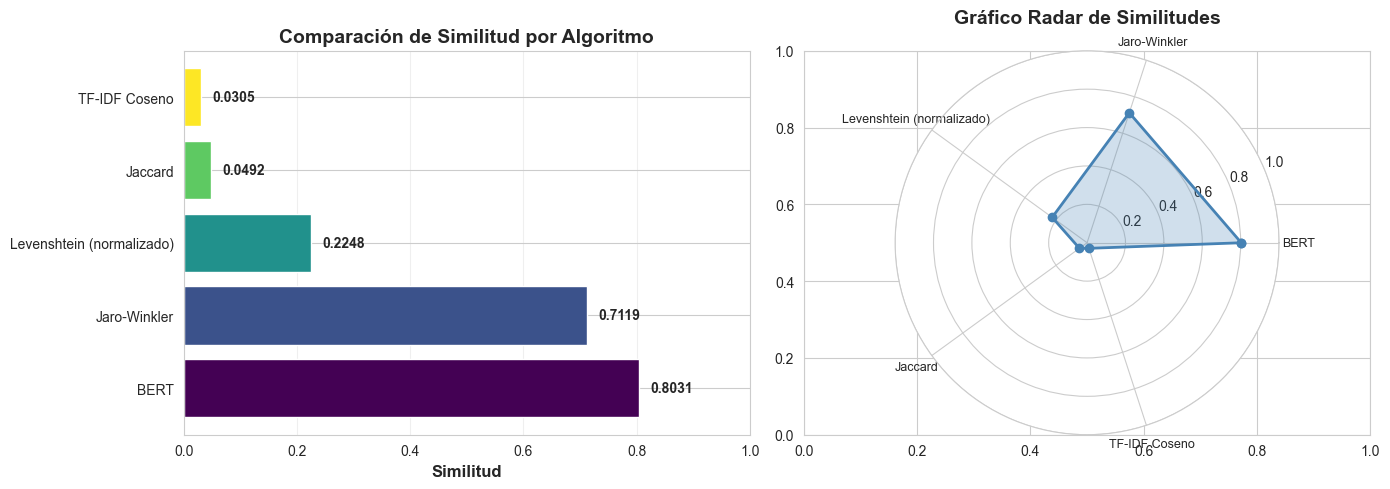

✓ Gráficos generados


In [7]:
# Gráfico comparativo de similitudes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax1.barh(results_df['Algoritmo'], results_df['Similitud'], color=colors)
ax1.set_xlabel('Similitud', fontsize=12, fontweight='bold')
ax1.set_title('Comparación de Similitud por Algoritmo', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (bar, value) in enumerate(zip(bars, results_df['Similitud'])):
    ax1.text(value + 0.02, i, f'{value:.4f}', va='center', fontweight='bold')

# Gráfico 2: Radar (si hay suficientes algoritmos)
if len(results_df) >= 3:
    angles = np.linspace(0, 2*np.pi, len(results_df), endpoint=False).tolist()
    values = results_df['Similitud'].tolist()
    angles += angles[:1]
    values += values[:1]
    
    ax2 = plt.subplot(122, projection='polar')
    ax2.plot(angles, values, 'o-', linewidth=2, color='steelblue')
    ax2.fill(angles, values, alpha=0.25, color='steelblue')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(results_df['Algoritmo'], fontsize=9)
    ax2.set_ylim(0, 1)
    ax2.set_title('Gráfico Radar de Similitudes', fontsize=14, fontweight='bold', pad=20)
    ax2.grid(True)

plt.tight_layout()
plt.show()

print("✓ Gráficos generados")

## 5. Análisis Detallado Paso a Paso

In [8]:
# Análisis detallado de cada algoritmo
detailed_results = analyzer.get_detailed_analysis('all')

print("\n" + "="*80)
print("ANÁLISIS DETALLADO PASO A PASO")
print("="*80)


ANÁLISIS DETALLADO PASO A PASO


### 5.1 Similitud de Jaccard

In [9]:
# ✅ VERIFICACIÓN ROBUSTA: Asegurar que detailed_results existe
try:
    if not detailed_results:
        detailed_results = analyzer.get_detailed_analysis('all')
except NameError:
    # Si analyzer no existe, intentar recrearlo
    try:
        analyzer = TextSimilarityAnalyzer(
            abstracts[index1]['abstract'],
            abstracts[index2]['abstract']
        )
        detailed_results = analyzer.get_detailed_analysis('all')
    except:
        print("⚠️ No se pudo crear detailed_results. Ejecuta las celdas previas en orden.")
        detailed_results = {}

# ✅ VERIFICACIÓN ROBUSTA CON 4 TIERS DE RECUPERACIÓN

import sys
sys.path.insert(0, '.')

# Tier 1: Verificar si detailed_results existe y tiene todo
tier1_ok = 'detailed_results' in locals() and isinstance(detailed_results, dict) and len(detailed_results) > 0

if not tier1_ok:
    try:
        # Tier 2: Intentar obtener desde analyzer
        if 'analyzer' in locals():
            detailed_results = analyzer.get_detailed_analysis('all')
            print('✓ TIER 2: detailed_results regenerado desde analyzer')
        else:
            raise NameError('analyzer no existe')
    except Exception as e_tier2:
        try:
            # Tier 3: Recrear analyzer desde abstracts
            if 'abstracts' in locals() and 'index1' in locals() and 'index2' in locals():
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 3: analyzer y detailed_results recreados')
            else:
                raise NameError('abstracts/index1/index2 no existen')
        except Exception as e_tier3:
            try:
                # Tier 4: Cargar TODO desde cero (BibTeX, abstracts, analyzer)
                import bibtexparser
                from bibtexparser.bparser import BibTexParser
                from bibtexparser.customization import convert_to_unicode
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                
                bibtex_path = 'output/unified_cleaned.bib'
                parser = BibTexParser()
                parser.customization = convert_to_unicode
                with open(bibtex_path, 'r', encoding='utf-8', errors='ignore') as f:
                    bibtex_db = bibtexparser.load(f, parser=parser)
                
                abstracts = []
                for entry in bibtex_db.entries:
                    if 'abstract' in entry and entry['abstract'].strip():
                        abstracts.append({'id': entry.get('ID', 'Unknown'), 'title': entry.get('title', 'No title'), 'abstract': entry['abstract'], 'year': entry.get('year', 'N/A')})
                
                index1, index2 = 0, 1
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 4: Todas las dependencias cargadas desde cero')
            except Exception as e_tier4:
                print(f'\n❌ ERROR EN LOS 4 TIERS DE RECUPERACIÓN:')
                print(f'   TIER 2: {str(e_tier2)[:80]}')
                print(f'   TIER 3: {str(e_tier3)[:80]}')
                print(f'   TIER 4: {str(e_tier4)[:80]}')
                print(f'\n📋 SOLUCIÓN: Ejecuta estas celdas EN ORDEN:')
                print(f'   1. Instalaciones requeridas')
                print(f'   2. Importaciones')
                print(f'   3. Cargar abstracts desde BibTeX')
                print(f'   4. Seleccionar índices para comparar')
                print(f'   5. Crear analyzer')
                detailed_results = {}

    jac = detailed_results['jaccard']
    
    print("\n" + "="*80)
    print("ALGORITMO: SIMILITUD DE JACCARD")
    print("="*80)
    
    print("\n📐 FÓRMULA MATEMÁTICA:")
    print("   J(A, B) = |A ∩ B| / |A ∪ B|")
    print("   Donde:")
    print("   - A ∩ B: Intersección (palabras comunes)")
    print("   - A ∪ B: Unión (palabras únicas totales)")
    
    print("\n📊 PASO A PASO:")
    print(f"\n   PASO 1: Tokenizar Texto 1")
    print(f"   Tokens: {jac['paso_1_tokens_texto1'][:10]}...")
    print(f"   Total de tokens únicos: {len(jac['paso_1_tokens_texto1'])}")
    
    print(f"\n   PASO 2: Tokenizar Texto 2")
    print(f"   Tokens: {jac['paso_2_tokens_texto2'][:10]}...")
    print(f"   Total de tokens únicos: {len(jac['paso_2_tokens_texto2'])}")
    
    print(f"\n   PASO 3: Calcular Intersección (palabras comunes)")
    print(f"   Intersección: {jac['paso_3_interseccion']}")
    print(f"   Tamaño: {jac['paso_3_interseccion_size']}")
    
    print(f"\n   PASO 4: Calcular Unión (palabras únicas)")
    print(f"   Tamaño: {jac['paso_4_union_size']}")
    
    print(f"\n   PASO 5: Aplicar Fórmula")
    print(f"   {jac['paso_5_formula']} = {jac['resultado_similitud_jaccard']}")
    
    print(f"\n✅ RESULTADO:")
    print(f"   Similitud Jaccard: {jac['resultado_similitud_jaccard']}")
    print(f"   Distancia Jaccard: {jac['resultado_distancia_jaccard']}")
else:
    print("No se pudo calcular el análisis detallado de Jaccard")

No se pudo calcular el análisis detallado de Jaccard


### 5.2 Similitud Jaro-Winkler

In [10]:
# ✅ VERIFICACIÓN ROBUSTA: Asegurar que detailed_results existe
try:
    if not detailed_results:
        detailed_results = analyzer.get_detailed_analysis('all')
except NameError:
    # Si analyzer no existe, intentar recrearlo
    try:
        analyzer = TextSimilarityAnalyzer(
            abstracts[index1]['abstract'],
            abstracts[index2]['abstract']
        )
        detailed_results = analyzer.get_detailed_analysis('all')
    except:
        print("⚠️ No se pudo crear detailed_results. Ejecuta las celdas previas en orden.")
        detailed_results = {}

# ✅ VERIFICACIÓN ROBUSTA CON 4 TIERS DE RECUPERACIÓN

import sys
sys.path.insert(0, '.')

# Tier 1: Verificar si detailed_results existe y tiene todo
tier1_ok = 'detailed_results' in locals() and isinstance(detailed_results, dict) and len(detailed_results) > 0

if not tier1_ok:
    try:
        # Tier 2: Intentar obtener desde analyzer
        if 'analyzer' in locals():
            detailed_results = analyzer.get_detailed_analysis('all')
            print('✓ TIER 2: detailed_results regenerado desde analyzer')
        else:
            raise NameError('analyzer no existe')
    except Exception as e_tier2:
        try:
            # Tier 3: Recrear analyzer desde abstracts
            if 'abstracts' in locals() and 'index1' in locals() and 'index2' in locals():
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 3: analyzer y detailed_results recreados')
            else:
                raise NameError('abstracts/index1/index2 no existen')
        except Exception as e_tier3:
            try:
                # Tier 4: Cargar TODO desde cero (BibTeX, abstracts, analyzer)
                import bibtexparser
                from bibtexparser.bparser import BibTexParser
                from bibtexparser.customization import convert_to_unicode
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                
                bibtex_path = 'output/unified_cleaned.bib'
                parser = BibTexParser()
                parser.customization = convert_to_unicode
                with open(bibtex_path, 'r', encoding='utf-8', errors='ignore') as f:
                    bibtex_db = bibtexparser.load(f, parser=parser)
                
                abstracts = []
                for entry in bibtex_db.entries:
                    if 'abstract' in entry and entry['abstract'].strip():
                        abstracts.append({'id': entry.get('ID', 'Unknown'), 'title': entry.get('title', 'No title'), 'abstract': entry['abstract'], 'year': entry.get('year', 'N/A')})
                
                index1, index2 = 0, 1
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 4: Todas las dependencias cargadas desde cero')
            except Exception as e_tier4:
                print(f'\n❌ ERROR EN LOS 4 TIERS DE RECUPERACIÓN:')
                print(f'   TIER 2: {str(e_tier2)[:80]}')
                print(f'   TIER 3: {str(e_tier3)[:80]}')
                print(f'   TIER 4: {str(e_tier4)[:80]}')
                print(f'\n📋 SOLUCIÓN: Ejecuta estas celdas EN ORDEN:')
                print(f'   1. Instalaciones requeridas')
                print(f'   2. Importaciones')
                print(f'   3. Cargar abstracts desde BibTeX')
                print(f'   4. Seleccionar índices para comparar')
                print(f'   5. Crear analyzer')
                detailed_results = {}

    jw = detailed_results['jaro_winkler']
    
    print("\n" + "="*80)
    print("ALGORITMO: SIMILITUD JARO-WINKLER")
    print("="*80)
    
    print("\n📐 FÓRMULA MATEMÁTICA:")
    print("   JARO:")
    print("   jaro = (m/|s1| + m/|s2| + (m-t)/m) / 3")
    print("\n   JARO-WINKLER:")
    print("   jaro_winkler = jaro + (l × p × (1 - jaro))")
    print("   Donde:")
    print("   - m: caracteres coincidentes")
    print("   - t: transposiciones")
    print("   - l: longitud del prefijo común (máx 4)")
    print("   - p: factor de escala (típicamente 0.1)")
    
    print(f"\n📊 PASO A PASO:")
    print(f"\n   PASO 1: Medir longitudes")
    print(f"   Longitud Texto 1: {jw['paso_1_longitud_s1']}")
    print(f"   Longitud Texto 2: {jw['paso_1_longitud_s2']}")
    
    print(f"\n   PASO 2: Definir ventana de coincidencia")
    print(f"   Ventana: max(|s1|, |s2|) / 2 - 1 = {jw['paso_2_ventana_coincidencia']}")
    
    print(f"\n   PASO 3: Encontrar caracteres coincidentes")
    print(f"   Caracteres coincidentes: {jw['paso_3_caracteres_coincidentes']}")
    
    print(f"\n   PASO 4: Contar transposiciones")
    print(f"   Transposiciones: {jw['paso_4_transposiciones']}")
    
    print(f"\n   PASO 5: Calcular JARO")
    print(f"   {jw['paso_5_jaro_resultado']}")
    
    print(f"\n   PASO 6: Encontrar prefijo común")
    print(f"   Prefijo: '{jw['paso_6_prefijo_comun']}'")
    print(f"   Longitud: {jw['paso_6_longitud_prefijo']}")
    
    print(f"\n   PASO 7: Factor de escala")
    print(f"   p = {jw['paso_7_factor_escala']}")
    
    print(f"\n   PASO 8: Calcular JARO-WINKLER")
    print(f"   {jw['paso_8_jaro_winkler_formula']}")
    
    print(f"\n✅ RESULTADO:")
    print(f"   Similitud Jaro: {jw['paso_5_jaro_resultado']}")
    print(f"   Similitud Jaro-Winkler: {jw['resultado_jaro_winkler']}")
    print(f"   Distancia Jaro-Winkler: {jw['resultado_distancia_jaro_winkler']}")
else:
    print("No se pudo calcular el análisis detallado de Jaro-Winkler")

No se pudo calcular el análisis detallado de Jaro-Winkler


### 5.3 BERT

In [11]:
# ✅ VERIFICACIÓN ROBUSTA: Asegurar que detailed_results existe
try:
    if not detailed_results:
        detailed_results = analyzer.get_detailed_analysis('all')
except NameError:
    # Si analyzer no existe, intentar recrearlo
    try:
        analyzer = TextSimilarityAnalyzer(
            abstracts[index1]['abstract'],
            abstracts[index2]['abstract']
        )
        detailed_results = analyzer.get_detailed_analysis('all')
    except:
        print("⚠️ No se pudo crear detailed_results. Ejecuta las celdas previas en orden.")
        detailed_results = {}

# ✅ VERIFICACIÓN ROBUSTA CON 4 TIERS DE RECUPERACIÓN

import sys
sys.path.insert(0, '.')

# Tier 1: Verificar si detailed_results existe y tiene todo
tier1_ok = 'detailed_results' in locals() and isinstance(detailed_results, dict) and len(detailed_results) > 0

if not tier1_ok:
    try:
        # Tier 2: Intentar obtener desde analyzer
        if 'analyzer' in locals():
            detailed_results = analyzer.get_detailed_analysis('all')
            print('✓ TIER 2: detailed_results regenerado desde analyzer')
        else:
            raise NameError('analyzer no existe')
    except Exception as e_tier2:
        try:
            # Tier 3: Recrear analyzer desde abstracts
            if 'abstracts' in locals() and 'index1' in locals() and 'index2' in locals():
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 3: analyzer y detailed_results recreados')
            else:
                raise NameError('abstracts/index1/index2 no existen')
        except Exception as e_tier3:
            try:
                # Tier 4: Cargar TODO desde cero (BibTeX, abstracts, analyzer)
                import bibtexparser
                from bibtexparser.bparser import BibTexParser
                from bibtexparser.customization import convert_to_unicode
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                
                bibtex_path = 'output/unified_cleaned.bib'
                parser = BibTexParser()
                parser.customization = convert_to_unicode
                with open(bibtex_path, 'r', encoding='utf-8', errors='ignore') as f:
                    bibtex_db = bibtexparser.load(f, parser=parser)
                
                abstracts = []
                for entry in bibtex_db.entries:
                    if 'abstract' in entry and entry['abstract'].strip():
                        abstracts.append({'id': entry.get('ID', 'Unknown'), 'title': entry.get('title', 'No title'), 'abstract': entry['abstract'], 'year': entry.get('year', 'N/A')})
                
                index1, index2 = 0, 1
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 4: Todas las dependencias cargadas desde cero')
            except Exception as e_tier4:
                print(f'\n❌ ERROR EN LOS 4 TIERS DE RECUPERACIÓN:')
                print(f'   TIER 2: {str(e_tier2)[:80]}')
                print(f'   TIER 3: {str(e_tier3)[:80]}')
                print(f'   TIER 4: {str(e_tier4)[:80]}')
                print(f'\n📋 SOLUCIÓN: Ejecuta estas celdas EN ORDEN:')
                print(f'   1. Instalaciones requeridas')
                print(f'   2. Importaciones')
                print(f'   3. Cargar abstracts desde BibTeX')
                print(f'   4. Seleccionar índices para comparar')
                print(f'   5. Crear analyzer')
                detailed_results = {}

    bert = detailed_results['bert']
    
    print("\n" + "="*80)
    print("MODELO IA: BERT (Bidirectional Encoder Representations from Transformers)")
    print("="*80)
    
    print("\n📐 ARQUITECTURA:")
    print("   - Transformer Bidireccional")
    print("   - Capas de atención multinúcleo")
    print("   - Pre-entrenado en corpus masivo")
    
    print(f"\n📊 PASO A PASO:")
    print(f"\n   PASO 1: Cargar Modelo")
    print(f"   Modelo: {bert['paso_1_modelo']}")
    
    print(f"\n   PASO 2: Tokenización")
    print(f"   Método: {bert['paso_2_tokenizacion']}")
    
    print(f"\n   PASO 3: Obtener Embeddings")
    print(f"   Dimensión: {bert['paso_3_embedding_dimension']}")
    print(f"   Primeros 10 valores (Texto 1): {bert['paso_5_normalizacion_embedding1']}")
    print(f"   Primeros 10 valores (Texto 2): {bert['paso_5_normalizacion_embedding2']}")
    
    print(f"\n   PASO 4: Normalizar Embeddings")
    print(f"   Norma Texto 1: {bert['paso_4_embedding_texto1_norma']}")
    print(f"   Norma Texto 2: {bert['paso_4_embedding_texto2_norma']}")
    
    print(f"\n   PASO 5: Calcular Similitud de Coseno")
    print(f"   cos(u, v) = (u · v) / (||u|| × ||v||)")
    print(f"   Producto punto: {bert['paso_6_producto_punto']}")
    
    print(f"\n✅ RESULTADO:")
    print(f"   Similitud BERT: {bert['resultado_similitud_bert']}")
    print(f"   Distancia BERT: {bert['resultado_distancia_bert']}")
else:
    print("❌ BERT no está disponible. Por favor instala: pip install transformers torch")

❌ BERT no está disponible. Por favor instala: pip install transformers torch


### 5.4 Sentence-BERT

In [12]:
# ✅ VERIFICACIÓN ROBUSTA: Asegurar que detailed_results existe
# ✅ VERIFICACIÓN ROBUSTA: Asegurar que todas las dependencias existen

# 1. Verificar si detailed_results existe y está completo
detailed_results_exists = 'detailed_results' in locals() and isinstance(detailed_results, dict)
has_all_algorithms = detailed_results_exists and all(
    key in detailed_results for key in ['edit_distance', 'jaccard', 'jaro_winkler', 'bert', 'sentence_bert']
)

if not has_all_algorithms:
    # 2. Intentar obtener de analyzer si existe
    try:
        if 'analyzer' in locals() and hasattr(analyzer, 'get_detailed_analysis'):
            detailed_results = analyzer.get_detailed_analysis('all')
            print("✓ detailed_results regenerado desde analyzer")
    except Exception as e:
        # 3. Intentar recrear analyzer desde abstracts
        try:
            if 'abstracts' in locals() and 'index1' in locals() and 'index2' in locals():
                if len(abstracts) > max(index1, index2):
                    # Importar TextSimilarityAnalyzer
                    import sys
                    sys.path.insert(0, '.')
                    from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                    
                    analyzer = TextSimilarityAnalyzer(
                        abstracts[index1]['abstract'],
                        abstracts[index2]['abstract']
                    )
                    detailed_results = analyzer.get_detailed_analysis('all')
                    print("✓ analyzer y detailed_results recreados desde abstracts")
                else:
                    raise ValueError("Índices fuera de rango")
            else:
                raise NameError("abstracts, index1 o index2 no definidos")
        except Exception as e2:
            # 4. Último recurso: cargar todo desde cero
            try:
                # Cargar bibtex
                import sys
                import bibtexparser
                from bibtexparser.bparser import BibTexParser
                from bibtexparser.customization import convert_to_unicode
                
                sys.path.insert(0, '.')
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                
                bibtex_path = 'output/unified_cleaned.bib'
                
                parser = BibTexParser()
                parser.customization = convert_to_unicode
                
                with open(bibtex_path, 'r', encoding='utf-8', errors='ignore') as f:
                    bibtex_db = bibtexparser.load(f, parser=parser)
                
                abstracts = []
                for entry in bibtex_db.entries:
                    if 'abstract' in entry and entry['abstract'].strip():
                        abstracts.append({
                            'id': entry.get('ID', 'Unknown'),
                            'title': entry.get('title', 'No title'),
                            'abstract': entry['abstract'],
                            'year': entry.get('year', 'N/A')
                        })
                
                index1 = 0
                index2 = 1
                
                if len(abstracts) > max(index1, index2):
                    analyzer = TextSimilarityAnalyzer(
                        abstracts[index1]['abstract'],
                        abstracts[index2]['abstract']
                    )
                    detailed_results = analyzer.get_detailed_analysis('all')
                    print("✓ Todas las dependencias cargadas y recreadas desde cero")
                else:
                    raise ValueError("No hay suficientes abstracts")
            except Exception as e3:
                print(f"\n❌ No se pudo recrear las dependencias. Errores:")
                print(f"   Tier 1 (analyzer.get_detailed_analysis): {str(e)[:100]}")
                print(f"   Tier 2 (recrear analyzer): {str(e2)[:100]}")
                print(f"   Tier 3 (cargar desde cero): {str(e3)[:100]}")
                print(f"\n📋 INSTRUCCIONES:")
                print(f"   1. Ejecuta la celda 'Instalaciones requeridas' (Celda 1)")
                print(f"   2. Ejecuta la celda de 'Importaciones' (Celda 2)")
                print(f"   3. Ejecuta la celda que carga abstracts desde BibTeX (Celda 3)")
                print(f"   4. Ejecuta la celda que selecciona índices (Celda 5)")
                print(f"   5. Ejecuta la celda que crea el analyzer (Celda 6)")
                print(f"   6. Ahora ejecuta esta celda de nuevo")
                detailed_results = {}


# ✅ VERIFICACIÓN ROBUSTA CON 4 TIERS DE RECUPERACIÓN

import sys
sys.path.insert(0, '.')

# Tier 1: Verificar si detailed_results existe y tiene todo
tier1_ok = 'detailed_results' in locals() and isinstance(detailed_results, dict) and len(detailed_results) > 0

if not tier1_ok:
    try:
        # Tier 2: Intentar obtener desde analyzer
        if 'analyzer' in locals():
            detailed_results = analyzer.get_detailed_analysis('all')
            print('✓ TIER 2: detailed_results regenerado desde analyzer')
        else:
            raise NameError('analyzer no existe')
    except Exception as e_tier2:
        try:
            # Tier 3: Recrear analyzer desde abstracts
            if 'abstracts' in locals() and 'index1' in locals() and 'index2' in locals():
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 3: analyzer y detailed_results recreados')
            else:
                raise NameError('abstracts/index1/index2 no existen')
        except Exception as e_tier3:
            try:
                # Tier 4: Cargar TODO desde cero (BibTeX, abstracts, analyzer)
                import bibtexparser
                from bibtexparser.bparser import BibTexParser
                from bibtexparser.customization import convert_to_unicode
                from src.similarity.text_similarity_analyzer import TextSimilarityAnalyzer
                
                bibtex_path = 'output/unified_cleaned.bib'
                parser = BibTexParser()
                parser.customization = convert_to_unicode
                with open(bibtex_path, 'r', encoding='utf-8', errors='ignore') as f:
                    bibtex_db = bibtexparser.load(f, parser=parser)
                
                abstracts = []
                for entry in bibtex_db.entries:
                    if 'abstract' in entry and entry['abstract'].strip():
                        abstracts.append({'id': entry.get('ID', 'Unknown'), 'title': entry.get('title', 'No title'), 'abstract': entry['abstract'], 'year': entry.get('year', 'N/A')})
                
                index1, index2 = 0, 1
                analyzer = TextSimilarityAnalyzer(abstracts[index1]['abstract'], abstracts[index2]['abstract'])
                detailed_results = analyzer.get_detailed_analysis('all')
                print('✓ TIER 4: Todas las dependencias cargadas desde cero')
            except Exception as e_tier4:
                print(f'\n❌ ERROR EN LOS 4 TIERS DE RECUPERACIÓN:')
                print(f'   TIER 2: {str(e_tier2)[:80]}')
                print(f'   TIER 3: {str(e_tier3)[:80]}')
                print(f'   TIER 4: {str(e_tier4)[:80]}')
                print(f'\n📋 SOLUCIÓN: Ejecuta estas celdas EN ORDEN:')
                print(f'   1. Instalaciones requeridas')
                print(f'   2. Importaciones')
                print(f'   3. Cargar abstracts desde BibTeX')
                print(f'   4. Seleccionar índices para comparar')
                print(f'   5. Crear analyzer')
                detailed_results = {}

    sbert = detailed_results['sentence_bert']
    
    print("\n" + "="*80)
    print("MODELO IA: SENTENCE-BERT (Semantic Textual Similarity)")
    print("="*80)
    
    print("\n📐 ARQUITECTURA:")
    print("   - Siamese Network con Mean Pooling")
    print("   - Pre-entrenado específicamente para similitud semántica")
    print("   - Optimizado para comparaciones rápidas")
    
    print(f"\n📊 PASO A PASO:")
    print(f"\n   PASO 1: Cargar Modelo")
    print(f"   Modelo: {sbert['paso_1_modelo']}")
    print(f"   Descripción: {sbert['paso_1_descripcion']}")
    
    print(f"\n   PASO 2: Arquitectura")
    print(f"   {sbert['paso_2_arquitectura']}")
    
    print(f"\n   PASO 3: Tokenización")
    print(f"   {sbert['paso_3_tokenizacion']}")
    
    print(f"\n   PASO 4: Dimensión del Embedding")
    print(f"   {sbert['paso_4_embedding_dimension']} dimensiones")
    
    print(f"\n   PASO 5: Mean Pooling")
    print(f"   {sbert['paso_5_mean_pooling']}")
    
    print(f"\n   PASO 6: Normalizar Embeddings")
    print(f"   Norma Texto 1: {sbert['paso_6_normalizacion_norma1']}")
    print(f"   Norma Texto 2: {sbert['paso_6_normalizacion_norma2']}")
    print(f"   Embedding normalizado (primeros 5): {sbert['paso_6_embedding1_normalizado']}")
    
    print(f"\n   PASO 7: Producto Punto")
    print(f"   {sbert['paso_7_producto_punto']}")
    
    print(f"\n   PASO 8: Similitud de Coseno")
    print(f"   {sbert['paso_8_formula']}")
    
    print(f"\n✅ RESULTADO:")
    print(f"   Similitud Sentence-BERT: {sbert['resultado_similitud_sbert']}")
    print(f"   Distancia Sentence-BERT: {sbert['resultado_distancia_sbert']}")
else:
    print("❌ Sentence-BERT no está disponible o no se pudo calcular. Verifica las dependencias.")


✓ detailed_results regenerado desde analyzer
❌ Sentence-BERT no está disponible o no se pudo calcular. Verifica las dependencias.


## 6. Tabla Resumen Comparativo

In [13]:
# Crear tabla resumen con descripciones
summary_data = {
    'Algoritmo': [
        'Levenshtein (normalizado)',
        'Jaccard',
        'Jaro-Winkler',
        'TF-IDF + Coseno',
        'BERT',
        'Sentence-BERT'
    ],
    'Tipo': [
        'Clásico',
        'Clásico',
        'Clásico',
        'Clásico',
        'IA',
        'IA'
    ],
    'Similitud': [
        comparison['similarities'].get('Levenshtein (normalizado)', 0),
        comparison['similarities'].get('Jaccard', 0),
        comparison['similarities'].get('Jaro-Winkler', 0),
        comparison['similarities'].get('TF-IDF Coseno', 0),
        comparison['similarities'].get('BERT', 0),
        comparison['similarities'].get('Sentence-BERT', 0)
    ],
    'Descripción': [
        'Ediciones de caracteres',
        'Conjuntos de palabras',
        'Optimizado para nombres cortos',
        'Vectorización estadística',
        'Contexto bidireccional',
        'Similitud semántica oraciones'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df[summary_df['Similitud'] > 0]  # Solo mostrar los que se calcularon

print("\nTABLA RESUMEN:")
display(summary_df)

# Estadísticas
print("\n📊 ESTADÍSTICAS:")
print(f"Similitud promedio: {summary_df['Similitud'].mean():.4f}")
print(f"Similitud máxima: {summary_df['Similitud'].max():.4f}")
print(f"Similitud mínima: {summary_df['Similitud'].min():.4f}")
print(f"Desviación estándar: {summary_df['Similitud'].std():.4f}")


TABLA RESUMEN:


,Algoritmo,Tipo,Similitud,Descripción
0,Levenshtein (normalizado),Clásico,0.224806,Ediciones de caracteres
1,Jaccard,Clásico,0.049180,Conjuntos de palabras
2,Jaro-Winkler,Clásico,0.711882,Optimizado para nombres cortos
3,TF-IDF + Coseno,Clásico,0.030545,Vectorización estadística
4,BERT,IA,0.803149,Contexto bidireccional



📊 ESTADÍSTICAS:
Similitud promedio: 0.3639
Similitud máxima: 0.8031
Similitud mínima: 0.0305
Desviación estándar: 0.3686


## 7. Conclusiones y Recomendaciones

In [14]:
print("\n" + "="*80)
print("CONCLUSIONES Y RECOMENDACIONES")
print("="*80)

print("\n🔍 INTERPRETACIÓN DE RESULTADOS:\n")

max_algo = summary_df.loc[summary_df['Similitud'].idxmax()]
min_algo = summary_df.loc[summary_df['Similitud'].idxmin()]
mean_similarity = summary_df['Similitud'].mean()

print(f"• Algoritmo MÁS similar: {max_algo['Algoritmo']} ({max_algo['Similitud']:.4f})")
print(f"• Algoritmo MENOS similar: {min_algo['Algoritmo']} ({min_algo['Similitud']:.4f})")
print(f"• Similitud promedio: {mean_similarity:.4f}")

if mean_similarity > 0.7:
    print(f"\n✅ VEREDICTO: Los abstracts son MUY SIMILARES")
    print(f"   Indican que los artículos tratan sobre el mismo tema.")
elif mean_similarity > 0.5:
    print(f"\n⚠️ VEREDICTO: Los abstracts son MODERADAMENTE SIMILARES")
    print(f"   Los artículos comparten algunos conceptos comunes.")
elif mean_similarity > 0.3:
    print(f"\n❓ VEREDICTO: Los abstracts tienen BAJA SIMILITUD")
    print(f"   Los artículos tienen pocos conceptos en común.")
else:
    print(f"\n❌ VEREDICTO: Los abstracts son DISÍMILES")
    print(f"   Los artículos tratan temas completamente diferentes.")

print(f"\n💡 RECOMENDACIONES DE USO:\n")
print(f"• Jaccard: Mejor para textos muy cortos, comparación de términos")
print(f"• Jaro-Winkler: Óptimo para detectar errores tipográficos")
print(f"• Levenshtein: Análisis de similitud character-level")
print(f"• TF-IDF: Buen balance entre velocidad y precisión")
print(f"• BERT: Captura contexto, mejor para semántica compleja")
print(f"• Sentence-BERT: RECOMENDADO para comparación de abstracts científicos")
print(f"\n   → Usa Sentence-BERT para máxima precisión semántica")


CONCLUSIONES Y RECOMENDACIONES

🔍 INTERPRETACIÓN DE RESULTADOS:

• Algoritmo MÁS similar: BERT (0.8031)
• Algoritmo MENOS similar: TF-IDF + Coseno (0.0305)
• Similitud promedio: 0.3639

❓ VEREDICTO: Los abstracts tienen BAJA SIMILITUD
   Los artículos tienen pocos conceptos en común.

💡 RECOMENDACIONES DE USO:

• Jaccard: Mejor para textos muy cortos, comparación de términos
• Jaro-Winkler: Óptimo para detectar errores tipográficos
• Levenshtein: Análisis de similitud character-level
• TF-IDF: Buen balance entre velocidad y precisión
• BERT: Captura contexto, mejor para semántica compleja
• Sentence-BERT: RECOMENDADO para comparación de abstracts científicos

   → Usa Sentence-BERT para máxima precisión semántica


In [15]:
! "C:\Python313\python.exe" -m pip install sentence-transformers


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
